Epoch 100/1000 - loss: 0.590393
Epoch 200/1000 - loss: 0.214648
Epoch 300/1000 - loss: 0.112286
Epoch 400/1000 - loss: 0.079093
Epoch 500/1000 - loss: 0.065459
Epoch 600/1000 - loss: 0.058109
Epoch 700/1000 - loss: 0.053279
Epoch 800/1000 - loss: 0.049764
Epoch 900/1000 - loss: 0.047087
Epoch 1000/1000 - loss: 0.045000
Trained parameters: m = [-0.50598638 -0.44780565  0.05899339 -0.3506085  -0.38140574], b = 0.999000
Sample inputs -> predictions: [-0.38880631 -0.36482376 -0.4543403  -0.33613023 -0.71853549]


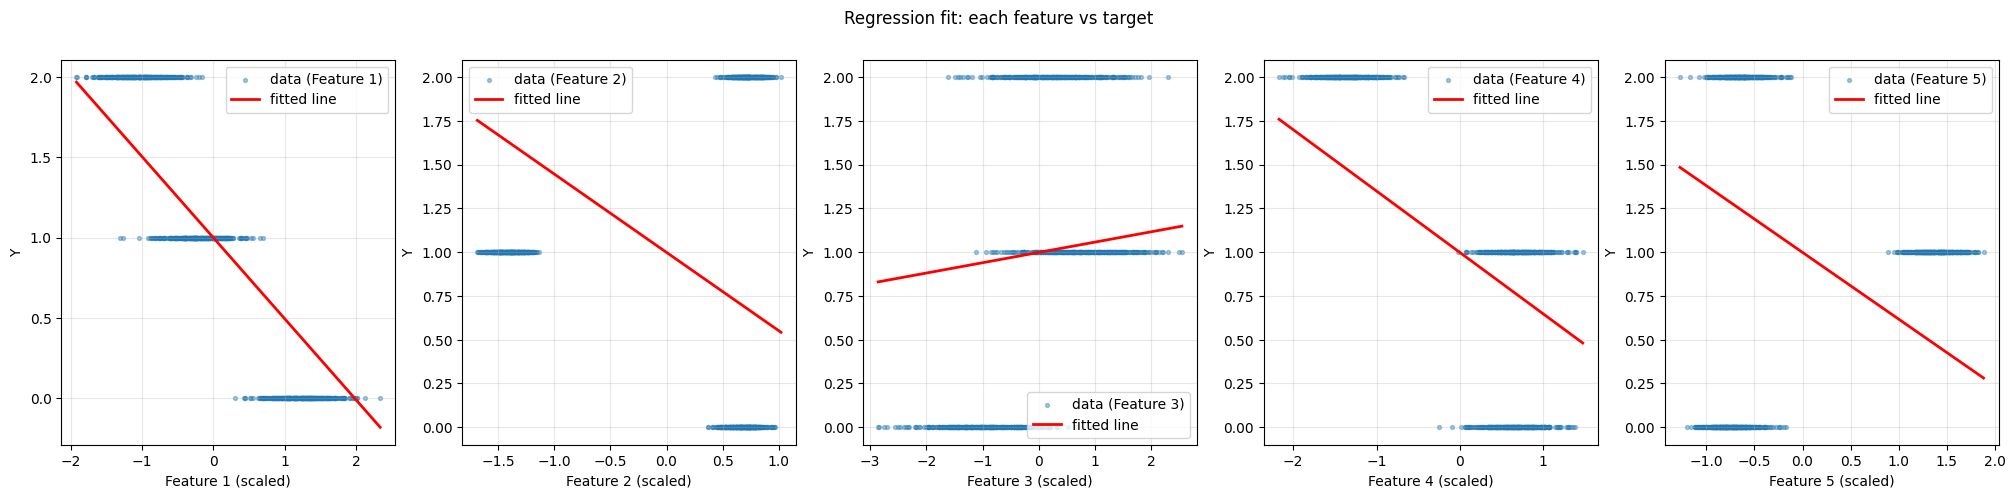

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# ========================
# 5D Dataset generation
# ========================
n_features = 5
X, Y = make_blobs(n_samples=1000, n_features=n_features, random_state=42)
Y = Y.reshape(-1, 1)  # ensure Y is column vector

# ========================
# Scale features
# ========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # fit and transform features

# ========================
# GD Regressor for 5D
# ========================
class GDRegressorND:
    def __init__(self, n_features, lr=0.01, epochs=1000):
        self.m = np.random.randn(n_features)  # initialize weights randomly
        self.b = 0.0
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, Y):
        X = np.asarray(X)
        y = np.asarray(Y).ravel()
        n_samples = X.shape[0]

        for i in range(self.epochs):
            preds = X.dot(self.m) + self.b
            error = y - preds

            grad_m = -2.0 / n_samples * X.T.dot(error)
            grad_b = -2.0 / n_samples * np.sum(error)

            self.m -= self.lr * grad_m
            self.b -= self.lr * grad_b

            if (i+1) % (self.epochs // 10 or 1) == 0:
                loss = np.mean(error**2)
                print(f"Epoch {i+1}/{self.epochs} - loss: {loss:.6f}")

        return self.m, self.b

    def predict(self, X):
        X = np.asarray(X)
        return X.dot(self.m) + self.b

# ========================
# Training
# ========================
gd_model = GDRegressorND(n_features=n_features, lr=0.01, epochs=1000)
gd_model.fit(X_scaled, Y)
print(f"Trained parameters: m = {gd_model.m}, b = {gd_model.b:.6f}")

# ========================
# Quick test/prediction example
# ========================
sample_X = np.random.randn(5, n_features)  # 3 sample inputs
sample_X_scaled = scaler.transform(sample_X)
preds = gd_model.predict(sample_X_scaled)
print("Sample inputs -> predictions:", preds)

# =========================
# Plot features vs target (all 5 features)
# =========================
feature_names = [f"Feature {i+1}" for i in range(n_features)]
fig, axes = plt.subplots(1, n_features, figsize=(5*n_features, 5))
x_values = X_scaled
y = Y.ravel()

for i in range(n_features):
    axes[i].scatter(x_values[:, i], y, s=8, alpha=0.4, label=f"data ({feature_names[i]})")
    xs = np.linspace(x_values[:, i].min(), x_values[:, i].max(), 200)
    ys = gd_model.m[i] * xs + gd_model.b
    axes[i].plot(xs, ys, color="red", linewidth=2, label="fitted line")
    axes[i].set_xlabel(f"{feature_names[i]} (scaled)")
    axes[i].set_ylabel("Y")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle("Regression fit: each feature vs target")
plt.show()
